### Calculate coefficient of variation as per Glüer et al. (1995)

Author: Simone Poncioni, MSB, ARTORG Center for Biomedical Engineering Research, University of Bern, Switzerland

Date: 07.2024

Update: 29.04.2025 for evaluating PE as per Schenk et al. (2020)

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import yaml
from collections import Counter, defaultdict

import matplotlib.pyplot as plt

In [4]:
def calculate_cv_gluer(infile: pd.DataFrame, outfile: dict, variable: str):
    """Function to calculate the coefficient of variation as per Glüer et al. 1995

    Args:
        infile (pd.DataFrame): DataFrame containing the imported yaml file with the simulation grouping information
        outfile (dict): simulation results file
        variable (str): variable to analyse (e.g. 'Stiffness', 'yield_force', etc.)
    """
    def dofs(results):
        '''
        Equation (7), calculating the degrees of fredom df_j of the measurements in the individuals
        '''
        counter = Counter()
        for value in results.values():
            key_part = value[0].split('/')[1]
            counter[key_part] += 1
        degrees_of_freedom = sum(count - 1 for count in counter.values())
        return degrees_of_freedom

    def precision_error(results):
        '''
        Equation (6), calculating the generic standard deviation sd of the measurements
        '''
        values_sorted = defaultdict(list)
        for _, value in results.items():
            key_part = value[0].split('/')[1]
            values_sorted[key_part].append(value[1])
        
        sum_tot = 0
        total_elements = 0
        df = 0

        # Calculating the internal mean, sum of squared differences, and degrees of freedom
        for key, values in values_sorted.items():
            internal_mean = sum(values) / len(values)
            total_elements += len(values)
            df += len(values) - 1  # Adding to degrees of freedom
            
            for xij in values:
                sum_tot += (xij - internal_mean) ** 2

        # Dividing by degrees of freedom
        variance = sum_tot / df
        sd = variance ** 0.5

        return sd, values_sorted

    def coefficient_of_variation(sd, values_sorted):
        '''
        Equation (5), calculating the coefficient of variation on a percentage basis
        '''
        HUNDRED = 100
        sum_means = 0
        m = len(values_sorted)

        for _, values in values_sorted.items():
            internal_mean = sum(values) / len(values)
            sum_means += internal_mean
        
        mean_of_means = sum_means / m
        cv_sd = (sd / mean_of_means) * HUNDRED
        return cv_sd

    out_samples = outfile['Sample'].values
    out_samples = [str(sample) for sample in out_samples]
    results_dict = {}
    for sample in out_samples:
        variable_res = outfile[outfile['Sample'] == sample][str(variable)]
        # add key 'variable' to results_dict (which has sample as key, infile['simulations']['folder_id'][sample] as value 0, and 'variable' as value 1)
        results_dict[sample] = [infile['simulations']['folder_id'][sample], variable_res.values[0]]

    # split results_dict into two dictionaries: results_r and results_t
    # ->>> results_r contains infile['simulations']['folder_id'][sample][-1] == 'R'
    # ->>> results_t contains infile['simulations']['folder_id'][sample][-1] == 'T'

    results_r = {}
    results_t = {}
    for key, value in results_dict.items():
        if value[0][-1] == 'R':
            results_r[key] = value
        elif value[0][-1] == 'T':
            results_t[key] = value
            
    property_r = [value[1] for value in results_r.values()]
    property_t = [value[1] for value in results_t.values()]

    property = [property_r, property_t]
    results = [results_r, results_t]
    site = ['RADIUS', 'TIBIA']

    df1 = pd.DataFrame()
    # as per Glüer et al. 1995
    for res, stiff, _site in zip(results, property, site):
        m = len(stiff)
        df = dofs(res)
        sd, values_sorted = precision_error(res)
        cv_sd = coefficient_of_variation(sd, values_sorted)
        # append to df
        df_temp = pd.DataFrame({'Variable': variable, 'm': m, 'df': df, 'sd': sd, 'cv_sd': cv_sd}, index=[_site])
        df1 = pd.concat([df1, df_temp])

    df1.index.name = 'Site'
    df1.reset_index(inplace=True)
    df1.set_index(['Site', 'Variable'], inplace=True)
    df1.reset_index(inplace=True)  # Reset index to make 'Site' and 'Variable' regular columns

    return df1


def pivot_dataframe(df: pd.DataFrame):
    df_res_pivot = df.pivot(index='Variable', columns='Site')
    df_res_pivot.columns = ['_'.join(col).strip() for col in df_res_pivot.columns.values]
    new_column_order = ['m_RADIUS', 'df_RADIUS', 'sd_RADIUS', 'cv_sd_RADIUS', 'm_TIBIA', 'df_TIBIA', 'sd_TIBIA', 'cv_sd_TIBIA']
    df_res_pivot = df_res_pivot[new_column_order]
    return df_res_pivot

In [6]:
basepath = Path("/home/simoneponcioni/Documents/01_PHD/03_Methods/HFE-WIP/QMSKI/gluer_repeatability/summaries/")
in_path = basepath / "simulations-repro.yaml"

with open(in_path, 'r') as f:
    infile = yaml.safe_load(f)

# * Indermaur et al. (in preparation, 2024)
outfile_path = basepath / 'REPRO_mech_param_FEA_noReg__V_00_noReg_FZ_MAX_sphere_changed.csv'
variables_to_analyse = ['Stiffness', 'yield_force', 'meanDA', 'apparent_yield_stress']
outfile = pd.read_csv(outfile_path, delimiter=',')

outfile['apparent_yield_stress'] = outfile['yield_force'] / outfile['CrossSection']

# Analyze the results as per Glüer et al. 1995
df_results = pd.DataFrame()

for var in variables_to_analyse:
    df_res = calculate_cv_gluer(infile, outfile, var)
    df_res_pivot = pivot_dataframe(df_res)
    df_results = pd.concat([df_results, df_res_pivot])

print(df_results.to_string())

# outfile_path = Path("/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/03_EVALUATION/08_hfe-evaluation/apparent_stress/001_repro_paper_data_summary.app_yield_stress.csv")
outfile_path = Path("/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/03_EVALUATION/04_rate-change/precision_error/002_repro_new_stress_data_summary.csv")
outfile = pd.read_csv(outfile_path, delimiter=',')

# filter out stiffness_1D_FZ_MAX and yield_force_FZ_MAX containing values > 1e5 or NaNs
outfile = outfile[(outfile['stiffness_1D_FZ_MAX'] < 1e5) & (outfile['yield_force_FZ_MAX'] < 1e5)]
outfile = outfile.dropna(subset=['stiffness_1D_FZ_MAX', 'yield_force_FZ_MAX'])

# variables_to_analyse = ['trabecular_average_DA', 'yield_force_FZ_MAX', 'cross_sectional_area', 'app_yield_stress']
variables_to_analyse = ['trabecular_average_DA', 'yield_force_FZ_MAX', 'apparent_yield_stress']

# Analyze the results as per Glüer et al. 1995
df_results = pd.DataFrame()

for var in variables_to_analyse:
    df_res = calculate_cv_gluer(infile, outfile, var)
    df_res_pivot = pivot_dataframe(df_res)
    df_results = pd.concat([df_results, df_res_pivot])

print(df_results.to_string())

                       m_RADIUS  df_RADIUS    sd_RADIUS  cv_sd_RADIUS  m_TIBIA  df_TIBIA     sd_TIBIA  cv_sd_TIBIA
Variable                                                                                                          
Stiffness                    95         62  1099.772061      2.542580      113        74  1164.026018     1.516933
yield_force                  95         62   262.802508      4.041041      113        74   353.107813     2.314418
meanDA                       95         62     0.041912      2.358588      113        74     0.030274     1.638764
apparent_yield_stress        95         62     1.192200      6.351819      113        74     0.439357     3.194945
                       m_RADIUS  df_RADIUS   sd_RADIUS  cv_sd_RADIUS  m_TIBIA  df_TIBIA    sd_TIBIA  cv_sd_TIBIA
Variable                                                                                                        
trabecular_average_DA        80         47    0.043426      2.488685       61       

In [1]:
m_RADIUS  df_RADIUS    sd_RADIUS  cv_sd_RADIUS  m_TIBIA  df_TIBIA     sd_TIBIA  cv_sd_TIBIA
Variable                                                                                                          
Stiffness                    95         62  1099.772061      2.542580      113        74  1164.026018     1.516933
yield_force                  95         62   262.802508      4.041041      113        74   353.107813     2.314418
meanDA                       95         62     0.041912      2.358588      113        74     0.030274     1.638764
apparent_yield_stress        95         62     1.192200      6.351819      113        74     0.439357     3.194945
                       m_RADIUS  df_RADIUS   sd_RADIUS  cv_sd_RADIUS  m_TIBIA  df_TIBIA    sd_TIBIA  cv_sd_TIBIA
Variable                                                                                                        
trabecular_average_DA        89         56    0.047622      2.716416       66        40    0.026215     1.581515
yield_force_FZ_MAX           89         56  410.171776      6.215843       66        40  325.973438     2.759148
cross_sectional_area         89         56    8.267301      2.669991       66        40   13.826884     1.394461
app_yield_stress             89         56    1.795222      8.243035       66        40    0.423681     3.513877

SyntaxError: invalid syntax (2504060384.py, line 1)

In [11]:
# Analyze the results as per Glüer et al. 1995
df_results = pd.DataFrame()

for var in variables_to_analyse:
    df_res = calculate_cv_gluer(infile, outfile, var)
    df_res_pivot = pivot_dataframe(df_res)
    df_results = pd.concat([df_results, df_res_pivot])

print(df_results.to_string())

             m_RADIUS  df_RADIUS    sd_RADIUS  cv_sd_RADIUS  m_TIBIA  df_TIBIA     sd_TIBIA  cv_sd_TIBIA
Variable                                                                                                
Stiffness          95         62  1099.772061      2.542580      113        74  1164.026018     1.516933
yield_force        95         62   262.802508      4.041041      113        74   353.107813     2.314418


In [ ]:
import pandas as pd
import numpy as np
from collections import defaultdict
from pathlib import Path

def calculate_cv_gluer_hrpqct(data_df, variables_to_analyze):
    """Calculate coefficient of variation as per Glüer et al. 1995 for HR-pQCT data
    
    Args:
        data_df (pd.DataFrame): DataFrame containing HR-pQCT data
        variables_to_analyze (list): List of base variable names to analyze
        
    Returns:
        pd.DataFrame: DataFrame containing CV results
    """
    # Make a copy of the dataframe to avoid modifying the original
    data_df = data_df.copy()
    
    print("Before conversion:")
    print(data_df[['nm_Tot.vBMD1', 'nm_Tb.vBMD1', 'nm_Ct.vBMD1']].head())
    
    # Convert nm_vBMD values from mg/cm³ to g/cm³ by dividing by 1000
    vbmd_vars = ['nm_Tot.vBMD', 'nm_Tb.vBMD', 'nm_Ct.vBMD']
    for base_var in vbmd_vars:
        for i in range(1, 4):  # suffixes 1, 2, 3
            col_name = f"{base_var}{i}"
            if col_name in data_df.columns:
                print(f"Converting {col_name}")
                data_df[col_name] = data_df[col_name] / 1000
    
    print("After conversion:")
    print(data_df[['nm_Tot.vBMD1', 'nm_Tb.vBMD1', 'nm_Ct.vBMD1']].head())
    
    results_all = pd.DataFrame()
    
    # Process data for each site (Radius=R, Tibia=T)
    for site in ['R', 'T']:
        site_data = data_df[data_df['Site.short'] == site].copy()
        # only keep rows where Grading1, Grading2, or Grading3 < 4
        # site_data = site_data[(site_data['Grading1'] < 4) | (site_data['Grading2'] < 4) | (site_data['Grading3'] < 4)]
        # site_data = site_data[site_data['PatRemark'] == 'F']

        for base_var in variables_to_analyze:
            # Identify columns for this variable (with suffixes 1, 2, 3)
            var_columns = [f"{base_var}{i}" for i in range(1, 4) if f"{base_var}{i}" in data_df.columns]
            
            if not var_columns:
                continue
            
            # Restructure data for CV calculation
            values_by_subject = defaultdict(list)
            
            for _, row in site_data.iterrows():
                subject_id = row['PatNo']
                for var_col in var_columns:
                    if pd.notna(row[var_col]):  # Only include non-NaN values
                        values_by_subject[subject_id].append(row[var_col])
            
            # Remove subjects with only one measurement
            values_by_subject = {k: v for k, v in values_by_subject.items() if len(v) >= 2}
            
            if not values_by_subject:
                continue
            
            # Calculate degrees of freedom
            df = sum(len(values) - 1 for values in values_by_subject.values())
            
            # Calculate precision error (SD)
            sum_squared_diff = 0
            
            for values in values_by_subject.values():
                internal_mean = sum(values) / len(values)
                for value in values:
                    sum_squared_diff += (value - internal_mean) ** 2
            
            if df == 0:
                continue
                
            variance = sum_squared_diff / df
            sd = np.sqrt(variance)
            
            # Calculate CV
            sum_means = sum(sum(values) / len(values) for values in values_by_subject.values())
            m = len(values_by_subject)
            mean_of_means = sum_means / m
            
            cv_sd = (sd / mean_of_means) * 100
            
            # Create result
            site_name = 'RADIUS' if site == 'R' else 'TIBIA'
            result = {
                'Site': site_name,
                'Variable': base_var,
                'm': m,
                'df': df,
                'sd': sd,
                'cv_sd': cv_sd
            }
            
            results_all = pd.concat([results_all, pd.DataFrame([result])])
    
    if not results_all.empty:
        results_all.reset_index(drop=True, inplace=True)
    
    return results_all


def calculate_cv_gluer_hrpqct_from_matlab(data_df, variables_to_analyze):
    """Calculate coefficient of variation as per Glüer et al. 1995 for HR-pQCT data
    
    This implementation follows the MATLAB approach where:
    1. Standard deviations are calculated per subject
    2. These SDs are combined using root-mean-square approach
    3. Mean values are averaged across subjects
    4. CV is calculated from the combined SD and mean
    
    Args:
        data_df (pd.DataFrame): DataFrame containing HR-pQCT data
        variables_to_analyze (list): List of base variable names to analyze
        
    Returns:
        pd.DataFrame: DataFrame containing CV results
    """
    results_all = pd.DataFrame()
    
    # Process data for each site (Radius=R, Tibia=T)
    for site in ['R', 'T']:
        site_data = data_df[data_df['Site.short'] == site].copy()
        
        for base_var in variables_to_analyze:
            # Identify columns for this variable (with suffixes 1, 2, 3)
            var_columns = [f"{base_var}{i}" for i in range(1, 4) if f"{base_var}{i}" in data_df.columns]
            
            if not var_columns:
                continue
                
            # Restructure data for CV calculation
            values_by_subject = defaultdict(list)
            for _, row in site_data.iterrows():
                subject_id = row['PatNo']
                for var_col in var_columns:
                    if pd.notna(row[var_col]):  # Only include non-NaN values
                        values_by_subject[subject_id].append(row[var_col])
            
            # Remove subjects with only one measurement (need at least 2 for SD)
            values_by_subject = {k: v for k, v in values_by_subject.items() if len(v) >= 2}
            
            if not values_by_subject:
                continue
                
            # Following the MATLAB approach:
            # 1. Calculate SD for each subject
            subject_sds = []
            subject_means = []
            
            for subject_id, values in values_by_subject.items():
                # Using numpy's std with ddof=1 for sample standard deviation
                subject_sd = np.std(values, ddof=1)
                subject_mean = np.mean(values)
                
                subject_sds.append(subject_sd)
                subject_means.append(subject_mean)
            
            # 2. Calculate the root-mean-square of the SDs (equivalent to MATLAB's approach)
            sd_all = np.sqrt(np.sum(np.array(subject_sds)**2) / len(subject_sds))
            
            # 3. Calculate the mean of means
            mean_of_means = np.sum(subject_means) / len(subject_means)
            
            # 4. Calculate CV
            cv_sd = (sd_all / mean_of_means) * 100
            
            # Create result
            site_name = 'RADIUS' if site == 'R' else 'TIBIA'
            result = {
                'Site': site_name,
                'Variable': base_var,
                'm': len(values_by_subject),
                'SD': sd_all,
                'Mean': mean_of_means,
                'CV': cv_sd
            }
            results_all = pd.concat([results_all, pd.DataFrame([result])])
    
    if not results_all.empty:
        results_all.reset_index(drop=True, inplace=True)
    
    return results_all


def pivot_dataframe(df):
    """Pivot the results dataframe for better display
    
    Args:
        df (pd.DataFrame): DataFrame with CV results
        
    Returns:
        pd.DataFrame: Pivoted dataframe
    """
    if df.empty:
        return pd.DataFrame()
        
    df_res_pivot = df.pivot(index='Variable', columns='Site')
    df_res_pivot.columns = ['_'.join(col).strip() for col in df_res_pivot.columns.values]
    
    # Define column order if all columns exist
    columns = ['m_RADIUS', 'df_RADIUS', 'sd_RADIUS', 'cv_sd_RADIUS', 
               'm_TIBIA', 'df_TIBIA', 'sd_TIBIA', 'cv_sd_TIBIA']
    
    # Only include columns that exist in the pivoted dataframe
    new_column_order = [col for col in columns if col in df_res_pivot.columns]
    
    if new_column_order:
        df_res_pivot = df_res_pivot[new_column_order]
        
    return df_res_pivot

excel_path = Path("/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/03_EVALUATION/04_rate-change/precision_error/denis/Repro_UPAT_TOTAL_Denis_Cleaned_004_incl_nm_003.xlsx")
# Read the Excel file
data_df = pd.read_excel(excel_path)

# Variables to analyze
variables_to_analyze = ['nm_Tot.vBMD', 'nm_Tb.vBMD', 'nm_Ct.vBMD', 'nm_Tb.BV.TV',
                        'nm_Tb.Ar', 'nm_Ct.Ar', 'nm_Ct.Th',
    'nm_Tb.N', 'nm_Tb.Th', 'nm_Tb.Sp', 'nm_Ct.Po', # Structural parameters
    'Stiffness', 'F.load', # Mechanical parameters
]
    #'uStiffness', 'uF.load', 



# Calculate CV using the Glüer method
results = calculate_cv_gluer_hrpqct(data_df, variables_to_analyze)
df_results = pivot_dataframe(results)
print(df_results.to_markdown())
df_results.to_csv('/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/03_EVALUATION/04_rate-change/precision_error/hrpqct_precision_results-tmp.csv')

Before conversion:
   nm_Tot.vBMD1  nm_Tb.vBMD1  nm_Ct.vBMD1
0         294.6        221.1        871.6
1         306.5        162.7        902.7
2         474.3        247.5        912.4
3         424.5        309.0        835.4
4         295.8        190.3        859.9
Converting nm_Tot.vBMD1
Converting nm_Tot.vBMD2
Converting nm_Tot.vBMD3
Converting nm_Tb.vBMD1
Converting nm_Tb.vBMD2
Converting nm_Tb.vBMD3
Converting nm_Ct.vBMD1
Converting nm_Ct.vBMD2
Converting nm_Ct.vBMD3
After conversion:
   nm_Tot.vBMD1  nm_Tb.vBMD1  nm_Ct.vBMD1
0        0.2946       0.2211       0.8716
1        0.3065       0.1627       0.9027
2        0.4743       0.2475       0.9124
3        0.4245       0.3090       0.8354
4        0.2958       0.1903       0.8599
| Variable    |   m_RADIUS |   df_RADIUS |     sd_RADIUS |   cv_sd_RADIUS |   m_TIBIA |   df_TIBIA |     sd_TIBIA |   cv_sd_TIBIA |
|:------------|-----------:|------------:|--------------:|---------------:|----------:|-----------:|-------------:|--

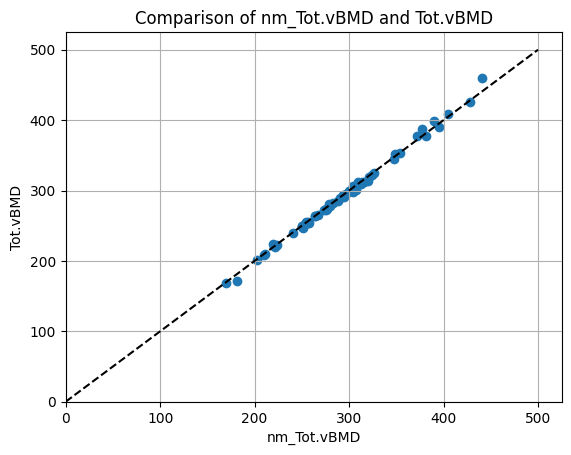

Index(['Name', 'DOB', 'PatNo', 'PatRemark', 'Comments', 'Site', 'Site.short',
       'Scanner-ID', 'Total-Area', 'Meas-Date1',
       ...
       'nm_Ct.Ar3', 'nm_Ct.vBMD3', 'nm_Ct.Pm3', 'nm_Ct.Po3', 'nm_Ct.Th3',
       'nm_Ct.Po.Dm3', 'Stiffness3', 'F.load3', 'uStiffness3', 'uF.load3'],
      dtype='object', length=158)


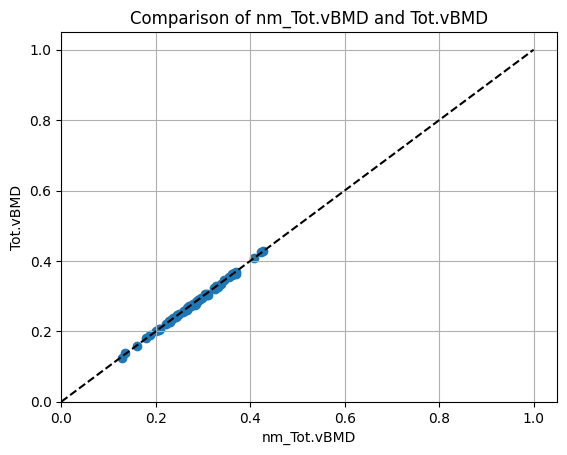

In [20]:
# plot differences between Tot.vBMD and nm_Tot.vBMD
plt.figure()
cols = data_df.columns
plt.scatter(data_df['nm_Tot.vBMD3'], data_df['Tot.vBMD3'])
plt.xlabel('nm_Tot.vBMD')
plt.ylabel('Tot.vBMD')
plt.title('Comparison of nm_Tot.vBMD and Tot.vBMD')
plt.plot([0, 500], [0, 500], 'k--')  # Diagonal line
plt.xlim(0)
plt.ylim(0)
plt.grid()
plt.show()

# plot differences between Tot.vBMD and nm_Tot.vBMD
plt.figure()
print(data_df.columns)
plt.scatter(data_df['nm_Tb.BV.TV3'], data_df['Tb.BV.TV3'])
plt.xlabel('nm_Tot.vBMD')
plt.ylabel('Tot.vBMD')
plt.title('Comparison of nm_Tot.vBMD and Tot.vBMD')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlim(0)
plt.ylim(0)
plt.grid()
plt.show()